In [24]:
# Parameters cell in Jupyter Notebook
stats_category = 'default_category'  # This default value will be replaced by Papermill
identifier = ''  # Default value, can be empty if not required

In [25]:
# Load environment variables
import dotenv
dotenv.load_dotenv('.env')

# Extract connection info
import os
mongodb_uri = os.getenv('MONGODB_URI')
postgres_host = os.getenv('POSTGRES_HOST')
postgres_port = os.getenv('POSTGRES_PORT')
postgres_db = os.getenv('POSTGRES_DB')
postgres_user = os.getenv('POSTGRES_USER')
postgres_password = os.getenv('POSTGRES_PASSWORD')

# Connect to MongoDB
from pymongo import MongoClient
mongo_client = MongoClient(mongodb_uri)
db = mongo_client['fdpdata']

# Connect to PostgreSQL
from sqlalchemy import create_engine
engine = create_engine(f'postgresql://{postgres_user}:{postgres_password}@{postgres_host}:{postgres_port}/{postgres_db}')


# Import commonly used libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Players

## All Players

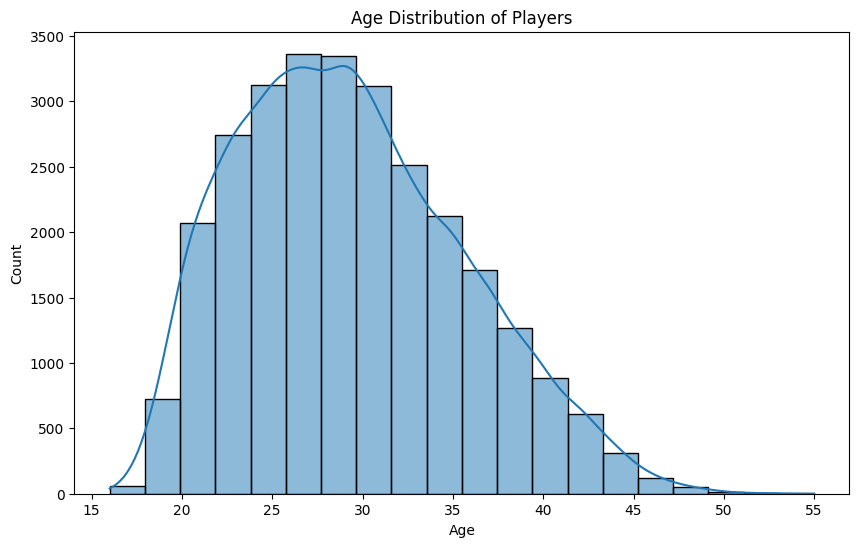

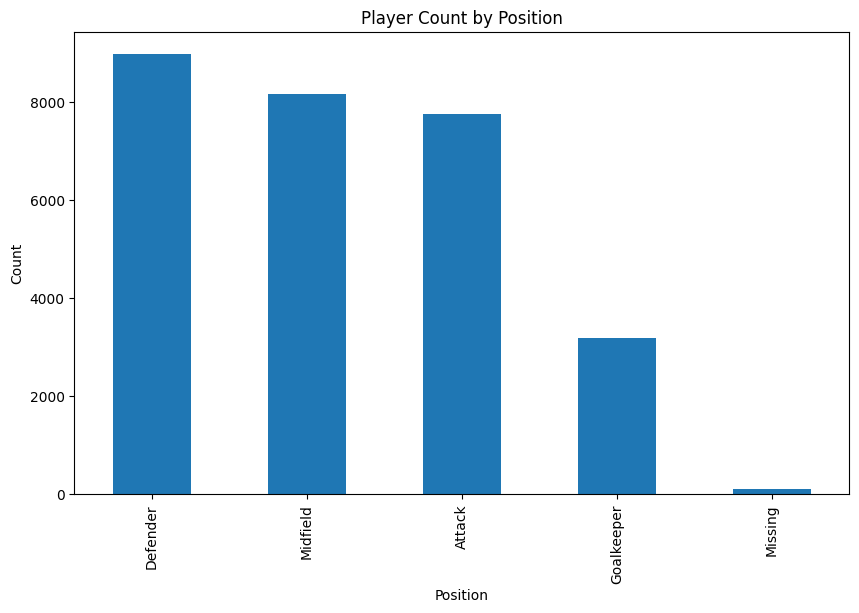

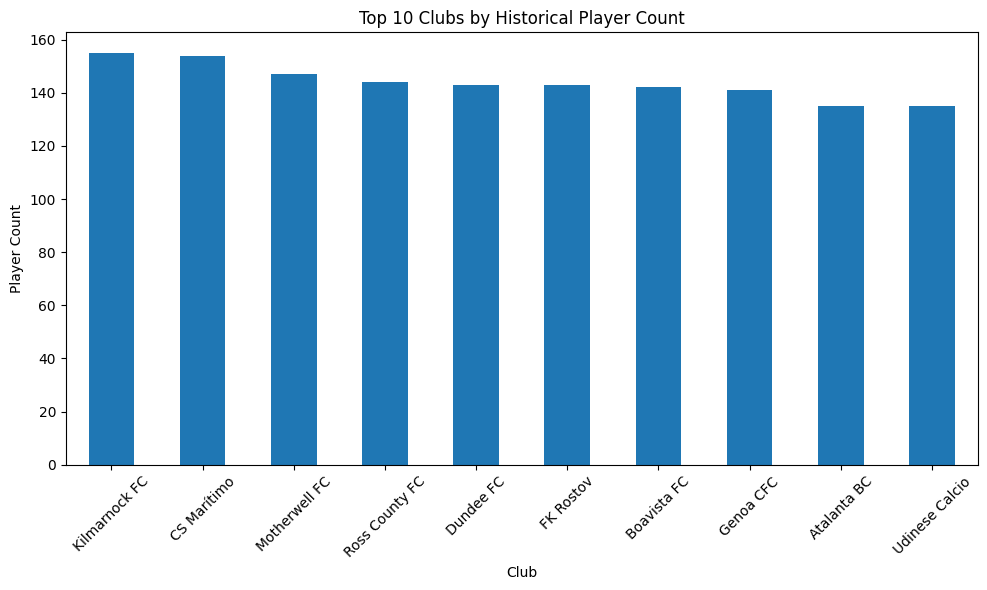

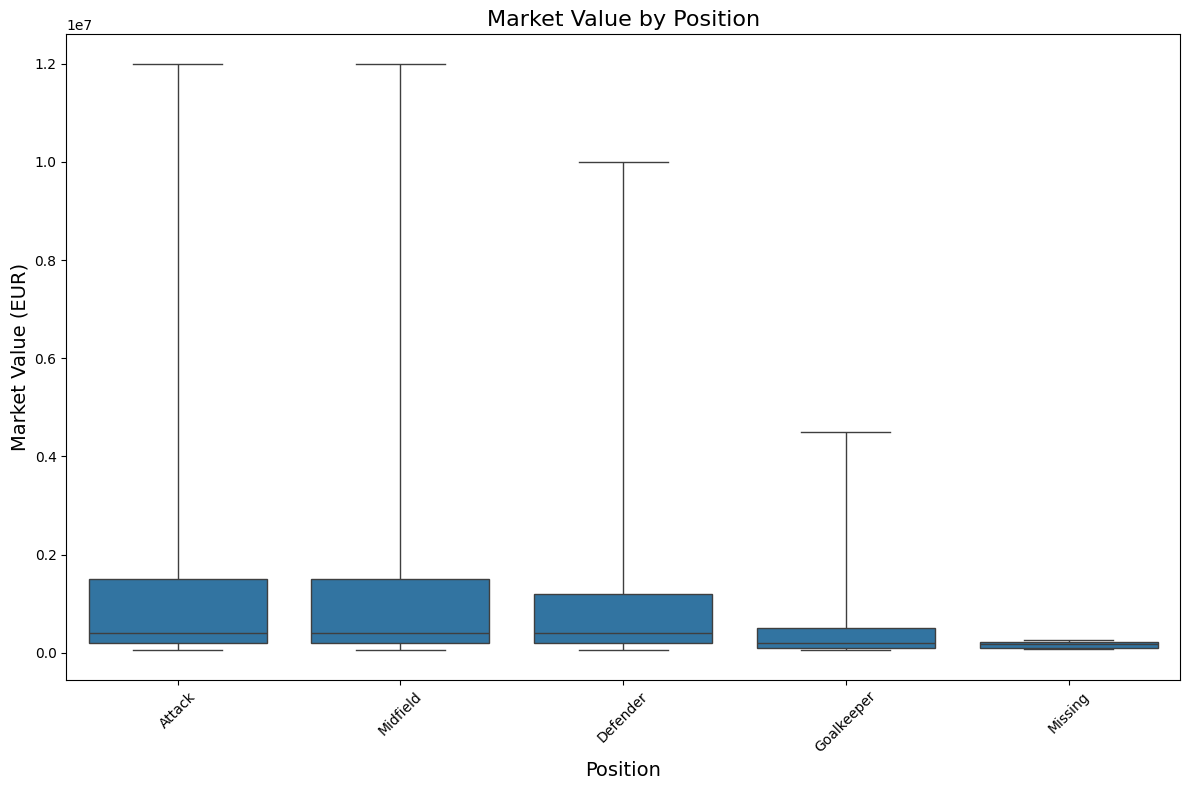

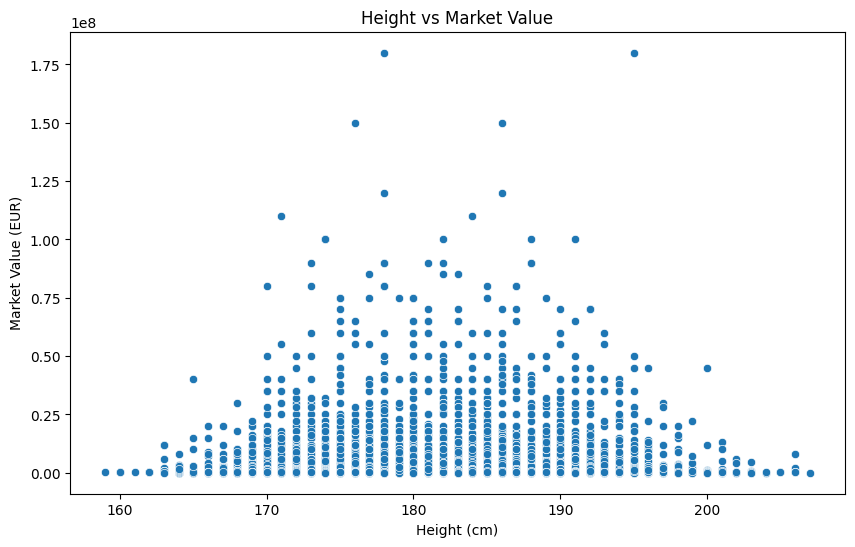

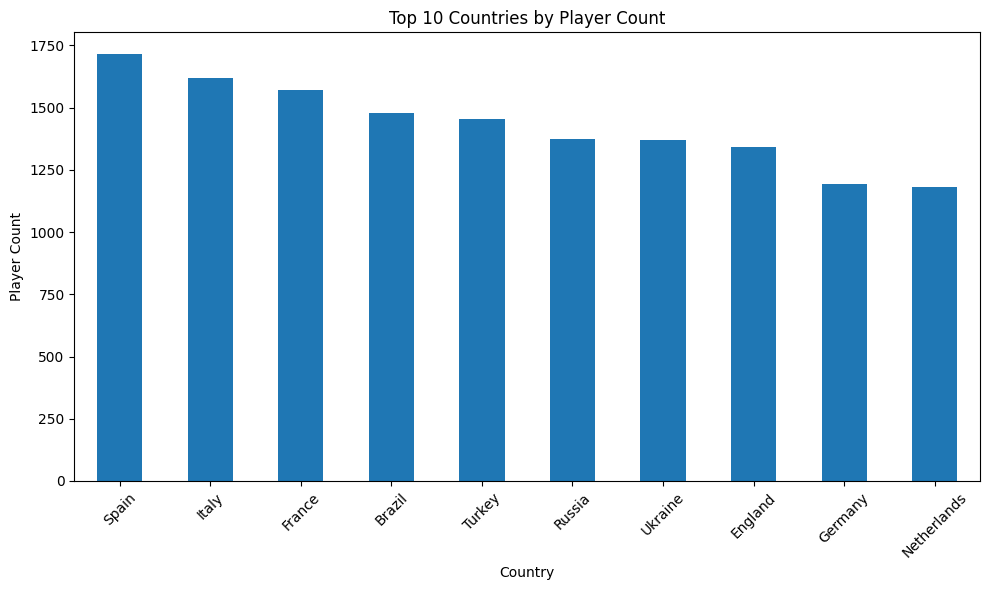

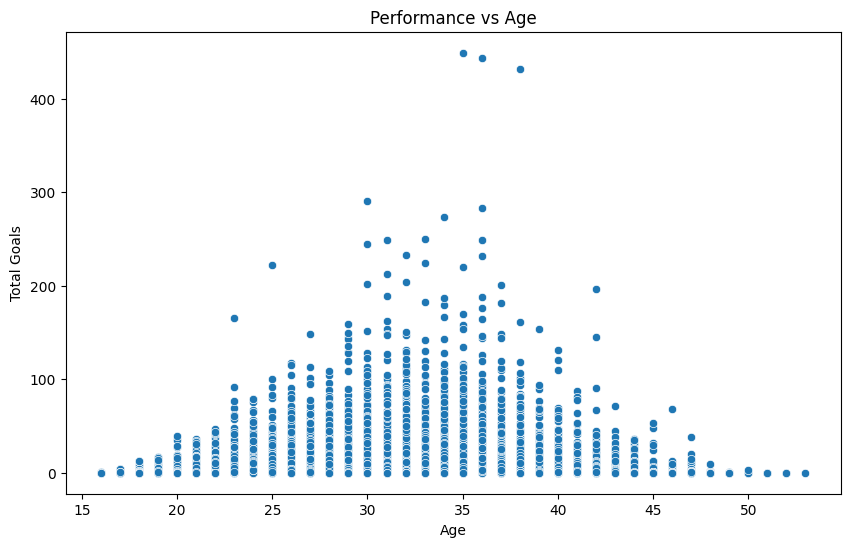

In [26]:
# Cell: All Players Analysis
if stats_category == 'allPlayers':

    # Ensure the output directory exists
    output_dir = './outputs/allPlayers'
    os.makedirs(output_dir, exist_ok=True)

    # Load data
    players_data = pd.read_sql("SELECT * from players", engine)
    appearances_collection = db.appearances

    # Aggregating total goals by player
    appearances_pipeline = [
        {
            '$group': {
                '_id': '$player_id',
                'total_goals': {
                    '$sum': '$goals'
                }
            }
        }
    ]
    appearances_data = list(appearances_collection.aggregate(appearances_pipeline))
    appearances_df = pd.DataFrame(appearances_data)
    appearances_df.rename(columns={'_id': 'player_id'}, inplace=True)

    # Merging data
    players_data = players_data.merge(appearances_df, on='player_id', how='left')

    # Standard Statistics

    # Age Distribution Analysis
    plt.figure(figsize=(10, 6))
    sns.histplot(players_data['age'], bins=20, kde=True)
    plt.title('Age Distribution of Players')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.savefig(os.path.join(output_dir, 'age_distribution.svg'))

    # Positional Analysis
    positions_count = players_data['position'].value_counts()
    plt.figure(figsize=(10, 6))
    positions_count.plot(kind='bar')
    plt.title('Player Count by Position')
    plt.xlabel('Position')
    plt.ylabel('Count')
    plt.savefig(os.path.join(output_dir, 'player_count_by_position.svg'))

    # Club Affiliation Diversity - Top 10
    plt.figure(figsize=(10, 6))
    top_clubs = players_data['current_club_name'].value_counts().head(10)
    top_clubs.plot(kind='bar')
    plt.title('Top 10 Clubs by Historical Player Count')
    plt.xlabel('Club')
    plt.ylabel('Player Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'top_club_affiliation_diversity.svg'))


    # Expert Statistics

    # Market Value Analysis
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=players_data, x='position', y='market_value_in_eur',
                whis=[5, 95], showfliers=False)
    plt.title('Market Value by Position', fontsize=16)
    plt.xlabel('Position', fontsize=14)
    plt.ylabel('Market Value (EUR)', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'market_value_by_position.svg'))

    # Physical Attributes Correlation
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=players_data, x='height_in_cm', y='market_value_in_eur')
    plt.title('Height vs Market Value')
    plt.xlabel('Height (cm)')
    plt.ylabel('Market Value (EUR)')
    plt.savefig(os.path.join(output_dir, 'height_vs_market_value.svg'))

    # International Representation - Top 10
    plt.figure(figsize=(10, 6))
    top_countries = players_data['country_of_citizenship'].value_counts().head(10)
    top_countries.plot(kind='bar')
    plt.title('Top 10 Countries by Player Count')
    plt.xlabel('Country')
    plt.xticks(rotation=45)
    plt.ylabel('Player Count')
    plt.tight_layout() 
    plt.savefig(os.path.join(output_dir, 'top_international_representation.svg'))

    # Performance and Age Relationship
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=players_data, x='age', y='total_goals')
    plt.title('Performance vs Age')
    plt.xlabel('Age')
    plt.ylabel('Total Goals')
    plt.savefig(os.path.join(output_dir, 'performance_vs_age.svg'))



## Single Player

In [27]:
# Cell: Single Player Analysis
if stats_category == 'player' and identifier:
    # Standard Statistics
    # Performance Over Seasons
    # Age vs Market Value
    # Disciplinary Record

    # Expert Statistics
    # Minute-by-Minute Performance
    # Value Trend
    # Positional Heatmap

    # (Analysis code goes here)
    print(f"Performed analysis for player {identifier}")


# Clubs

## All Clubs

In [28]:
# Cell: All Clubs Analysis
if stats_category == 'allClubs':
    # Standard Statistics
    # Average Age per Club
    # Squad Size Comparison
    # Net Transfer Records
    # Foreigners Percentage

    # Expert Statistics
    # Club Performance Over Seasons
    # Transfer Record Trends
    # Financial Analysis

    # (Analysis code goes here)
    print("Performed All Clubs analysis")


## Single Club

In [29]:
# Cell: Single Club Analysis
if stats_category == 'club' and identifier:
    # Standard Statistics
    # Season Performance
    # Top Scorers and Assist Providers
    # Transfer Activity Overview

    # Expert Statistics
    # Tactical Analysis
    # Performance in Different Competitions
    # Financial Analysis

    # (Analysis code goes here)
    print(f"Performed analysis for club {identifier}")


# Competitions

# All Competitions

In [30]:
# Cell: All Competitions Analysis
if stats_category == 'allCompetitions':
    # Standard Statistics
    # Team Performance in Latest Season
    # Top Goal Scorers
    # Attendance Trends

    # Expert Statistics
    # Historical Trends in Competition
    # Competition Popularity
    # Referee Analysis

    # (Analysis code goes here)
    print("Performed All Competitions analysis")


## Single Competition